## Analyse Exploratoire (EDA) des données

L'EDA a pour but connaître les données avant de faire quoi que ce soit de sophistiqué. L'objectif est de répondre à des questions simples mais fondamentales sur le dataset GDELT Bénin et d'en tiré les premières statistiques utiles.

## Sources de données — Events vs GKG

Le projet exploite deux tables complémentaires de GDELT qui
répondent à des questions différentes.

---

### GDELT Events
**"Qui a fait quoi à qui, où et quand ?"**

Chaque ligne est un **événement géopolitique** — une action
concrète entre deux acteurs (pays, organisation, individu).
C'est une base **quantitative et structurée**.

### GDELT GKG (Global Knowledge Graph)
**"Comment les médias parlent-ils du Bénin, et sur quels sujets ?"**

Chaque ligne est un **article de presse** analysé — thèmes
détectés, entités nommées, ton éditorial. C'est une base
**qualitative et sémantique**.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    plt.style.use("seaborn-v0_8")
except Exception:
    pass

## 1. Chargement des données

> Le chemin est relatif à la racine du repo.  
> Si l'exécution est sur **Google Colab**, remplacez `DATA_PATH` par le chemin Google Drive.

In [2]:
# ── Chemins vers les données nettoyées ──────────────────────────────────────
# Option A : Local (VS Code, Jupyter classique)
EVENTS_PATH = Path('..') / 'data' / 'processed' / 'events_cleaned.csv'
GKG_PATH    = Path('..') / 'data' / 'processed' / 'gkg_cleaned.csv'

# Option B : Google Colab (décommenter si nécessaire)
# from google.colab import drive
# drive.mount('/content/drive')
# EVENTS_PATH = '/content/drive/MyDrive/hackathon/data/processed/events_cleaned.csv'
# GKG_PATH    = '/content/drive/MyDrive/hackathon/data/processed/gkg_cleaned.csv'

# ── Chargement Events ────────────────────────────────────────────────────────
df = pd.read_csv(EVENTS_PATH, low_memory=False)
pd.set_option('display.max_columns', None)
print(f'✅ Events chargé  : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

# ── Chargement GKG ───────────────────────────────────────────────────────────
df_gkg = pd.read_csv(GKG_PATH, low_memory=False)
print(f'✅ GKG chargé     : {df_gkg.shape[0]:,} lignes × {df_gkg.shape[1]} colonnes')
print(f'   Colonnes GKG   : {list(df_gkg.columns)}')


✅ Events chargé  : 27,317 lignes × 46 colonnes
✅ GKG chargé     : 24,453 lignes × 9 colonnes
   Colonnes GKG   : ['Date', 'SourceCommonName', 'Persons', 'Organizations', 'Locations', 'Counts', 'V2Tone', 'TranslationInfo', 'translation_source_langs']


## 2. Structure du dataset

In [5]:
# 2.1 Aperçu général 
print('=' * 60)
print('APERÇU GÉNÉRAL')
print('=' * 60)
print(f"Nombre d'événements  : {df.shape[0]:,}")
print(f"Nombre de colonnes   : {df.shape[1]}")
print(f"Période couverte     : {df['SQLDATE'].min()} → {df['SQLDATE'].max()}")
print(f"Mémoire utilisée     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print('=' * 60)
print(f"Nombre d'événements  : {df_gkg.shape[0]:,}")
print(f"Nombre de colonnes   : {df_gkg.shape[1]}")
print(f"Mémoire utilisée     : {df_gkg.memory_usage(deep=True).sum() / 1e6:.1f} MB")

APERÇU GÉNÉRAL
Nombre d'événements  : 27,317
Nombre de colonnes   : 46
Période couverte     : 20250101 → 20251231
Mémoire utilisée     : 39.6 MB
Nombre d'événements  : 24,453
Nombre de colonnes   : 9
Mémoire utilisée     : 23.0 MB


In [6]:
# 2.2 Types de colonnes dataset Events
print('\nTYPES DE COLONNES')
print('-' * 40)
print(df.dtypes.to_string())


TYPES DE COLONNES
----------------------------------------
GLOBALEVENTID              int64
SQLDATE                    int64
MonthYear                  int64
Year                       int64
FractionDate             float64
Actor1Code                object
Actor1Name                object
Actor1CountryCode         object
Actor1Type1Code           object
Actor2Code                object
Actor2Name                object
Actor2CountryCode         object
Actor2Type1Code           object
IsRootEvent                int64
EventCode                  int64
EventBaseCode              int64
EventRootCode              int64
QuadClass                  int64
GoldsteinScale           float64
NumMentions                int64
NumSources                 int64
NumArticles                int64
AvgTone                  float64
Actor1Geo_Type             int64
Actor1Geo_FullName        object
Actor1Geo_CountryCode     object
Actor1Geo_ADM1Code        object
Actor1Geo_Lat            float64
Actor1Geo_Long  

In [7]:
# 2.3 Valeurs manquantes dataset Events
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    '% manquant': missing_pct
}).query('`Valeurs manquantes` > 0').sort_values('% manquant', ascending=False)

print('\nCOLONNES AVEC VALEURS MANQUANTES')
print('-' * 40)
print(missing_df.to_string())



COLONNES AVEC VALEURS MANQUANTES
----------------------------------------
                       Valeurs manquantes  % manquant
Actor2Type1Code                     18641        68.2
Actor1Type1Code                     15394        56.4
Actor2CountryCode                   14306        52.4
Actor1CountryCode                   12190        44.6
Actor2Geo_Long                       7177        26.3
Actor2Geo_FeatureID                  7177        26.3
Actor2Name                           7177        26.3
Actor2Code                           7177        26.3
Actor2Geo_ADM1Code                   7177        26.3
Actor2Geo_Lat                        7177        26.3
Actor2Geo_FullName                   7177        26.3
Actor2Geo_CountryCode                7177        26.3
Actor1Code                           2253         8.2
Actor1Name                           2253         8.2
Actor1Geo_CountryCode                2253         8.2
Actor1Geo_FullName                   2253         8.2
Actor1G

## 3. Analyse approfondir des données GDELT

Selon le codebook GDELT, on se concentre sur les champs pertinents pour le Bénin. Les données GKG et events ont déja été néttoyé dans le notebook data_cleaning.ipynb et stocké dans data/processed/


### 3.1 Types d'événements
Objectif: visualiser les catégories dominantes et la répartition des thèmes centré sur la coopération ou les conflits.
Graphiques: top 10 `Evènements` + barres `Catégorie Evènement`.

**Les quatres grandes catégories d'évenements du dataset Events**

- Coopération verbale   (discours, déclarations positives)
- Coopération matérielle (aide, accords signés, visites)
- Conflit verbal        (critiques, menaces, rejets)
- Conflit matériel      (violence, attaques, sanctions)


TYPES D'ÉVÉNEMENTS (CAMEO)

Top 10 types d'événements :
EventRootLabel
Consultations                  6884
Déclarations publiques         4008
Coopération diplomatique       3711
Appels / Demandes              1892
Critiques / Désapprobations    1512
Combats                        1418
Coercition                     1348
Intention de coopérer          1095
Aide / Assistance               933
Céder / Concéder                857


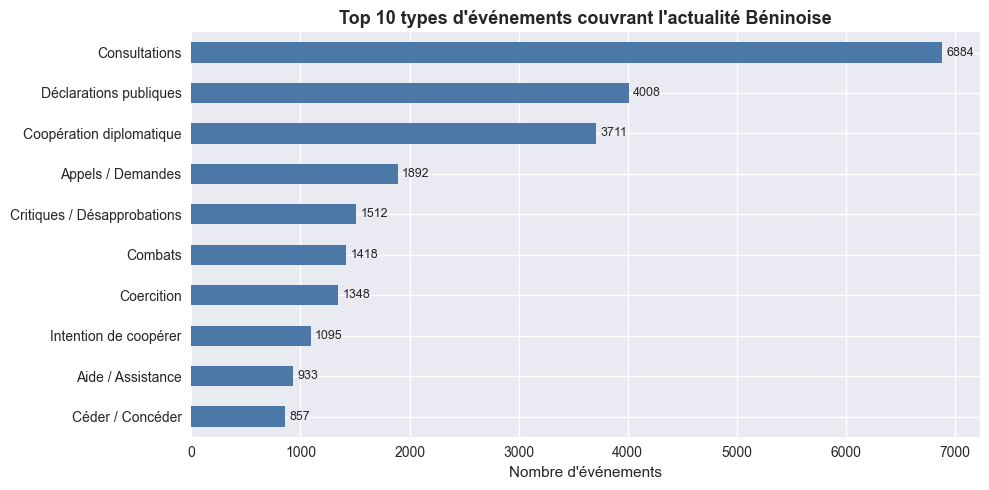


Répartition QuadClass :
                        Nombre  % du total
QuadClass                                 
Coopération verbale      17590        64.4
Coopération matérielle    2758        10.1
Conflit verbal            3263        11.9
Conflit matériel          3706        13.6


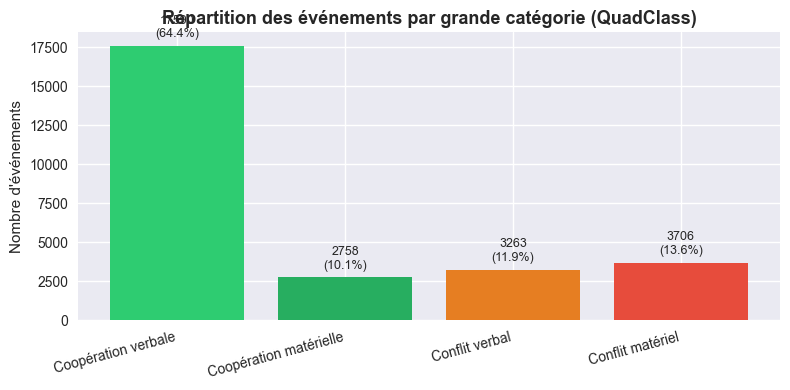

In [8]:
# ── Mappings CAMEO ───────────────────────────────────────────────────────────
cameo_root_map = {
    '01': 'Déclarations publiques',
    '02': 'Appels / Demandes',
    '03': 'Intention de coopérer',
    '04': 'Consultations',
    '05': 'Coopération diplomatique',
    '06': 'Coopération matérielle',
    '07': 'Aide / Assistance',
    '08': 'Céder / Concéder',
    '09': 'Investigations',
    '10': 'Exigences',
    '11': 'Critiques / Désapprobations',
    '12': 'Rejets',
    '13': 'Menaces',
    '14': 'Protestations',
    '15': 'Posture militaire',
    '16': 'Réduction des relations',
    '17': 'Coercition',
    '18': 'Attaques / Agressions',
    '19': 'Combats',
    '20': 'Violence de masse',
}

quadclass_map = {
    1: 'Coopération verbale',
    2: 'Coopération matérielle',
    3: 'Conflit verbal',
    4: 'Conflit matériel',
}

# ── 3.1 EventRootCode avec descriptions ─────────────────────────────────────
print("\n" + "=" * 60)
print("TYPES D'ÉVÉNEMENTS (CAMEO)")
print("=" * 60)

if 'EventRootCode' in df.columns:
    # Normaliser le code en string 2 chiffres
    df['EventRootCode_str'] = (
        df['EventRootCode']
        .astype(str)
        .str.strip()
        .str.zfill(2)
    )

    # Remplacer le code par la description
    df['EventRootLabel'] = df['EventRootCode_str'].map(cameo_root_map).fillna('Inconnu')

    # Top 10
    event_root_counts = df['EventRootLabel'].value_counts().head(10)

    print("\nTop 10 types d'événements :")
    print(event_root_counts.to_string())

    # Graphique
    fig, ax = plt.subplots(figsize=(10, 5))
    event_root_counts.sort_values().plot(kind='barh', ax=ax, color='#4C78A8')
    ax.set_title("Top 10 types d'événements couvrant l'actualité Béninoise", fontsize=13, fontweight='bold')
    ax.set_xlabel("Nombre d'événements")
    ax.set_ylabel("")  # le label de l'axe Y est inutile, les barres parlent d'elles-mêmes
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)  # ajouter les valeurs sur les barres
    plt.tight_layout()
    plt.show()

else:
    print("Colonne EventRootCode absente.")

# ── 3.2 QuadClass avec descriptions ─────────────────────────────────────────
if 'QuadClass' in df.columns:
    quad_counts = df['QuadClass'].value_counts().sort_index()
    quad_counts_named = quad_counts.rename(index=quadclass_map)

    quad_table = pd.DataFrame({
        'Nombre': quad_counts_named,
        '% du total': (quad_counts_named / len(df) * 100).round(1),
    })

    print("\nRépartition QuadClass :")
    print(quad_table.to_string())

    # Couleurs par type — vert pour coopération, rouge pour conflit
    colors = {
        'Coopération verbale':    '#2ecc71',
        'Coopération matérielle': '#27ae60',
        'Conflit verbal':         '#e67e22',
        'Conflit matériel':       '#e74c3c',
    }
    bar_colors = [colors.get(label, '#aaaaaa') for label in quad_counts_named.index]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(quad_counts_named.index, quad_counts_named.values, color=bar_colors)
    ax.set_title('Répartition des événements par grande catégorie (QuadClass)', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel("Nombre d'événements")
    ax.bar_label(bars, labels=[f"{v}\n({v/len(df)*100:.1f}%)" for v in quad_counts_named.values],
                 padding=4, fontsize=9)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

else:
    print("Colonne QuadClass absente.")

### 3.2 — Événements par localité (département)
**Objectif :** Cartographier la répartition des types d'événements par département béninois.
Identifier si les conflits sont concentrés dans certaines zones et si les événements impliquent des acteurs locaux ou étrangers.

Bénin (national) correspond à une localisation non précise de l'évenemnent

In [39]:
# Codes ADM1 qui ne sont pas béninois
codes_etrangers = [
    'NI', 'NI37', 'NI11', 'NI05', 'NI00', 'NI36',  # Nigeria
    'FR', 'FR00',                                      # France
    'GH', 'GH01',                                      # Ghana
    'TO',                                              # Togo
    'NG', 'NG08',                                      # Nigeria (autre code)
    'UV',                                              # Burkina Faso
    'UK', 'UKH9',                                      # Royaume-Uni
    'GA',                                              # Gabon
    'IV82',                                            # Côte d'Ivoire
    'US',                                              # États-Unis
]

# Voir combien ça représente
mask_etrangers = df['ActionGeo_ADM1Code'].isin(codes_etrangers)
print(f"Événements avec ADM1 étranger : {mask_etrangers.sum():,}")
print(f"Pourcentage : {mask_etrangers.mean()*100:.1f}%")

# Supprimer ces lignes du dataset
df_clean2 = df[~mask_etrangers].copy()
print(f"\nAprès suppression : {len(df_clean2):,} événements")

Événements avec ADM1 étranger : 3,533
Pourcentage : 12.9%

Après suppression : 23,784 événements


Total après nettoyage ADM1    : 23,784
Localisés au niveau département : 21,802
Niveau national uniquement      : 1,982

Répartition par département :
Departement
Borgou     21758
Atacora       35
Plateau        7
Couffo         2


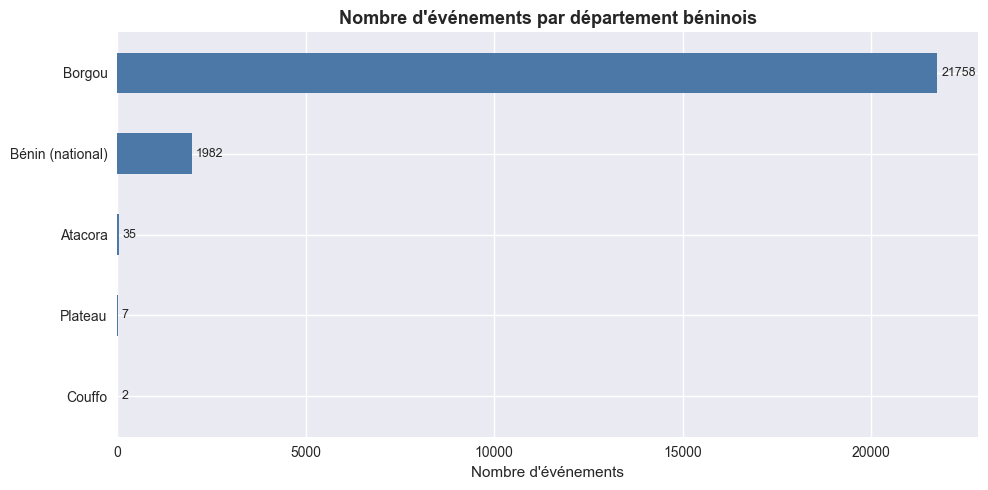

In [41]:
# ── Stratégie combinée de localisation ───────────────────────────────────────

adm1_benin = {
    'BN01': 'Alibori',   'BN02': 'Atacora',
    'BN03': 'Atlantique','BN04': 'Borgou',
    'BN05': 'Collines',  'BN06': 'Couffo',
    'BN07': 'Donga',     'BN08': 'Littoral',
    'BN09': 'Mono',      'BN10': 'Ouémé',
    'BN11': 'Plateau',   'BN12': 'Zou',
    'BN':   'Bénin (national)',
}

# Codes ADM1 clairement étrangers → à exclure
codes_etrangers = {
    'NI','NI37','NI11','NI05','NI00','NI36',
    'FR','FR00','GH','GH01','TO','NG','NG08',
    'UV','UK','UKH9','GA','IV82','US',
}

def coords_to_dept(lat, lon):
    dept_bbox = {
        'Alibori':    (10.5, 12.4, 2.0, 3.9),
        'Atacora':    (9.8,  12.0, 0.8, 2.2),
        'Atlantique': (6.1,   6.9, 1.9, 2.8),
        'Borgou':     (8.5,  11.5, 2.0, 3.8),
        'Collines':   (7.5,   9.3, 1.8, 3.0),
        'Couffo':     (6.8,   7.5, 1.4, 2.0),
        'Donga':      (8.8,  10.2, 0.5, 1.9),
        'Littoral':   (6.3,   6.5, 2.3, 2.5),
        'Mono':       (6.2,   7.2, 1.2, 1.8),
        'Ouémé':      (6.3,   7.2, 2.4, 3.0),
        'Plateau':    (6.8,   8.0, 2.6, 3.5),
        'Zou':        (7.0,   8.2, 1.8, 2.7),
    }
    for dept, (lat_min, lat_max, lon_min, lon_max) in dept_bbox.items():
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return dept
    return None

ville_to_dept = {
    'cotonou':'Littoral', 'porto-novo':'Ouémé', 'parakou':'Borgou',
    'abomey':'Zou', 'natitingou':'Atacora', 'kandi':'Alibori',
    'lokossa':'Mono', 'ouidah':'Atlantique', 'bohicon':'Zou',
    'djougou':'Donga', 'save':'Collines', 'abomey-calavi':'Atlantique',
    'godomey':'Atlantique', 'malanville':'Alibori', 'nikki':'Borgou',
    'aplahoue':'Couffo', 'pobè':'Plateau', 'ketou':'Plateau',
}

def infer_dept(row):
    adm1 = str(row.get('ActionGeo_ADM1Code', ''))

    # Exclure les codes étrangers
    if adm1 in codes_etrangers:
        return None

    # Priorité 1 — ADM1Code béninois précis
    if adm1 in adm1_benin and adm1 != 'BN':
        return adm1_benin[adm1]

    # Priorité 2 — Ville dans FullName
    fullname = str(row.get('ActionGeo_FullName', '')).lower()
    for ville, dept in ville_to_dept.items():
        if ville in fullname:
            return dept

    # Priorité 3 — Bbox GPS
    lat = row.get('ActionGeo_Lat')
    lon = row.get('ActionGeo_Long')
    if pd.notna(lat) and pd.notna(lon):
        dept = coords_to_dept(lat, lon)
        if dept:
            return dept

    # Sinon national
    return 'Bénin (national)'

df['Departement'] = df.apply(infer_dept, axis=1)

# Retirer les lignes avec ADM1 étranger (None)
df_benin = df[df['Departement'].notna()].copy()

# Stats de résolution
dept_counts = df_benin['Departement'].value_counts()
dept_precise = dept_counts[dept_counts.index != 'Bénin (national)']
print(f"Total après nettoyage ADM1    : {len(df_benin):,}")
print(f"Localisés au niveau département : {dept_precise.sum():,}")
print(f"Niveau national uniquement      : {dept_counts.get('Bénin (national)', 0):,}")
print(f"\nRépartition par département :")
print(dept_precise.to_string())


fig, ax = plt.subplots(figsize=(10, 5))
dept_counts.sort_values().plot(kind='barh', ax=ax, color='#4C78A8')
ax.set_title("Nombre d'événements par département béninois", fontsize=13, fontweight='bold')
ax.set_xlabel("Nombre d'événements")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.show()


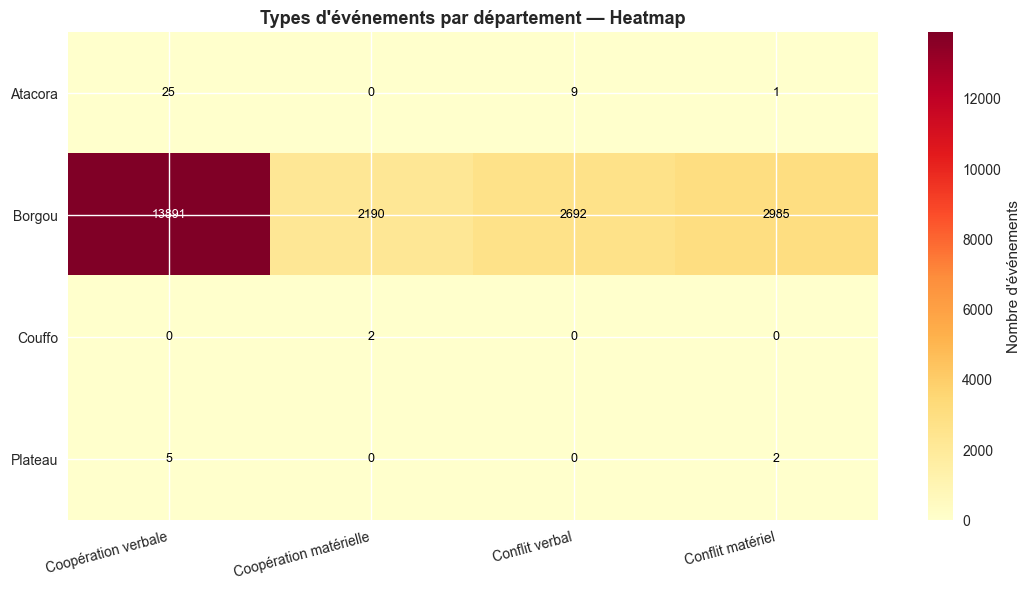

In [42]:
# ── 3.2.2 Types d'événements par département (heatmap) ─────────────────────
dept_quad = (
    df[~df['Departement'].isin(['Inconnu / International', 'Bénin (national)'])]
    .groupby(['Departement', 'QuadLabel'])
    .size()
    .unstack(fill_value=0)
)

# Ordonner les colonnes par logique coopération → conflit
col_order = [c for c in ['Coopération verbale', 'Coopération matérielle',
                          'Conflit verbal', 'Conflit matériel'] if c in dept_quad.columns]
dept_quad = dept_quad[col_order]

fig, ax = plt.subplots(figsize=(11, 6))
import numpy as np

im = ax.imshow(dept_quad.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(dept_quad.columns)))
ax.set_xticklabels(dept_quad.columns, rotation=15, ha='right')
ax.set_yticks(range(len(dept_quad.index)))
ax.set_yticklabels(dept_quad.index)

# Annoter chaque cellule avec sa valeur
for i in range(len(dept_quad.index)):
    for j in range(len(dept_quad.columns)):
        val = dept_quad.values[i, j]
        ax.text(j, i, str(val), ha='center', va='center', fontsize=9,
                color='black' if val < dept_quad.values.max() * 0.6 else 'white')

plt.colorbar(im, ax=ax, label="Nombre d'événements")
ax.set_title("Types d'événements par département — Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Les acteurs impliqués dans ces événements sont-ils béninois ou étrangers ?


Dimension des événements (Nationale vs International) :
interaction_type
Nationale        14553
International    12764

→ 46.7% des événements impliquent au moins un acteur étranger


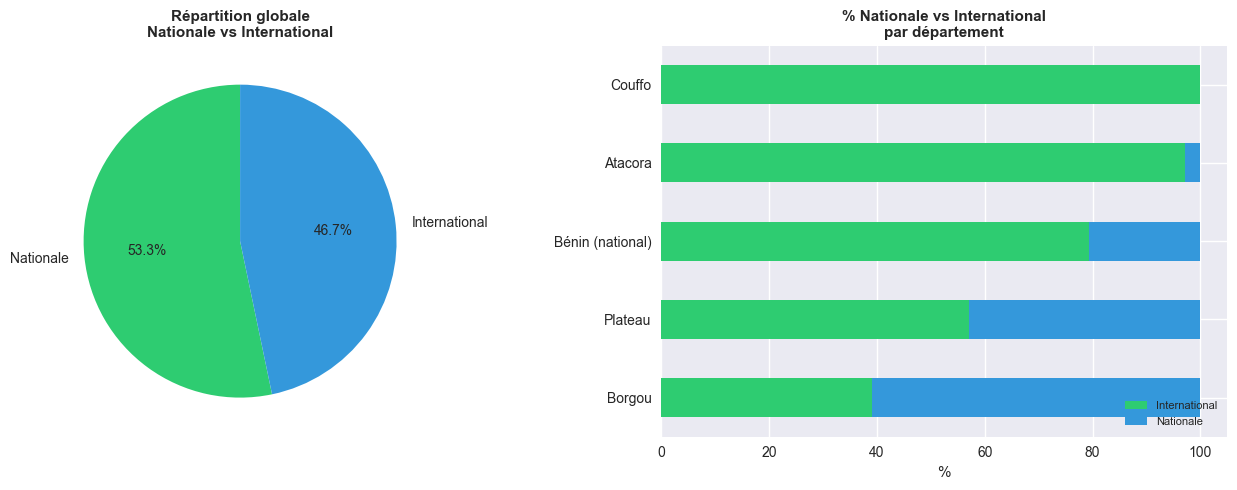

In [44]:
# ── 3.2.3 Dimension nationale vs international ──────────────────────────────
df['interaction_type'] = 'Mixte / Indéfini'

mask_local = (
    (df['Actor1CountryCode'].isin(['BEN']) | df['Actor1CountryCode'].isna()) &
    (df['Actor2CountryCode'].isin(['BEN']) | df['Actor2CountryCode'].isna())
)
mask_inter = (
    (~df['Actor1CountryCode'].isin(['BEN']) & df['Actor1CountryCode'].notna()) |
    (~df['Actor2CountryCode'].isin(['BEN']) & df['Actor2CountryCode'].notna())
)
df.loc[mask_local, 'interaction_type'] = 'Nationale'
df.loc[mask_inter, 'interaction_type'] = 'International'

print("\nDimension des événements (Nationale vs International) :")
inter_counts = df['interaction_type'].value_counts()
print(inter_counts.to_string())
print(f"\n→ {inter_counts.get('International', 0) / len(df) * 100:.1f}% des événements impliquent au moins un acteur étranger")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie globale
colors_pie = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].pie(inter_counts.values, labels=inter_counts.index,
            autopct='%1.1f%%', colors=colors_pie[:len(inter_counts)],
            startangle=90)
axes[0].set_title("Répartition globale\nNationale vs International", fontsize=11, fontweight='bold')

# Par département
dept_inter = (
    df[df['Departement'].isin(adm1_benin.values())]
    .groupby(['Departement', 'interaction_type'])
    .size()
    .unstack(fill_value=0)
)
if 'International' in dept_inter.columns:
    dept_inter_pct = (dept_inter.div(dept_inter.sum(axis=1), axis=0) * 100).round(1)
    dept_inter_pct = dept_inter_pct.sort_values('International', ascending=True)
    dept_inter_pct.plot(kind='barh', ax=axes[1], stacked=True,
                        color=['#2ecc71', '#3498db', '#bdc3c7'][:len(dept_inter_pct.columns)])
    axes[1].set_title("% Nationale vs International\npar département", fontsize=11, fontweight='bold')
    axes[1].set_xlabel("%")
    axes[1].set_ylabel("")
    axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()


### 3.3 — Acteurs les plus présents par type d'événement
**Objectif :** Identifier quels acteurs nommés (pays, organisations, leaders) sont associés aux événements coopératifs vs conflictuels au Bénin.


On retire d'abord les acteurs génériques ou dont la nomination n'est pas significative

In [13]:
# ── Nettoyage des acteurs génériques ────────────────────────────────────────
acteurs_generiques = {
    'GOVERNMENT', 'POLICE', 'MILITARY', 'OFFICIAL', 'MINISTER',
    'CITIZEN', 'PEOPLE', 'MEDIA', 'LEADER', 'AUTHORITY',
    'ADMINISTRATION', 'FORCES', 'UNIT', 'OFFICIAL', 'PRESIDENT',
    'PRIME MINISTER', 'MINISTER', 'LAWMAKER', 'SENATE', 'PARLIAMENT',
    'GOVERNOR', 'HOSPITAL', 'AFRICA', 'MINIST', 'SOLDIER',
}

print("=" * 60)
print("Q6 — ACTEURS PAR TYPE D'ÉVÉNEMENT")
print("=" * 60)

# Combiner Actor1 et Actor2 avec leur QuadLabel
actors_df = pd.concat([
    df[['Actor1Name', 'QuadLabel', 'Actor1CountryCode']].rename(
        columns={'Actor1Name': 'ActorName', 'Actor1CountryCode': 'CountryCode'}),
    df[['Actor2Name', 'QuadLabel', 'Actor2CountryCode']].rename(
        columns={'Actor2Name': 'ActorName', 'Actor2CountryCode': 'CountryCode'}),
], ignore_index=True)

# Nettoyer
actors_df = actors_df[
    actors_df['ActorName'].notna() &
    (~actors_df['ActorName'].str.strip().str.upper().isin(acteurs_generiques)) &
    (actors_df['ActorName'].str.strip() != '') &
    (actors_df['QuadLabel'] != 'Inconnu')
].copy()

actors_df['ActorName'] = actors_df['ActorName'].str.strip().str.title()

# Exclure "Benin" et "Benin City" car omniprésents et peu informatifs
actors_df = actors_df[~actors_df['ActorName'].isin(['Benin', 'Benin City'])]

print(f"\nNombre d'acteurs uniques (après nettoyage) : {actors_df['ActorName'].nunique()}")


Q6 — ACTEURS PAR TYPE D'ÉVÉNEMENT

Nombre d'acteurs uniques (après nettoyage) : 971


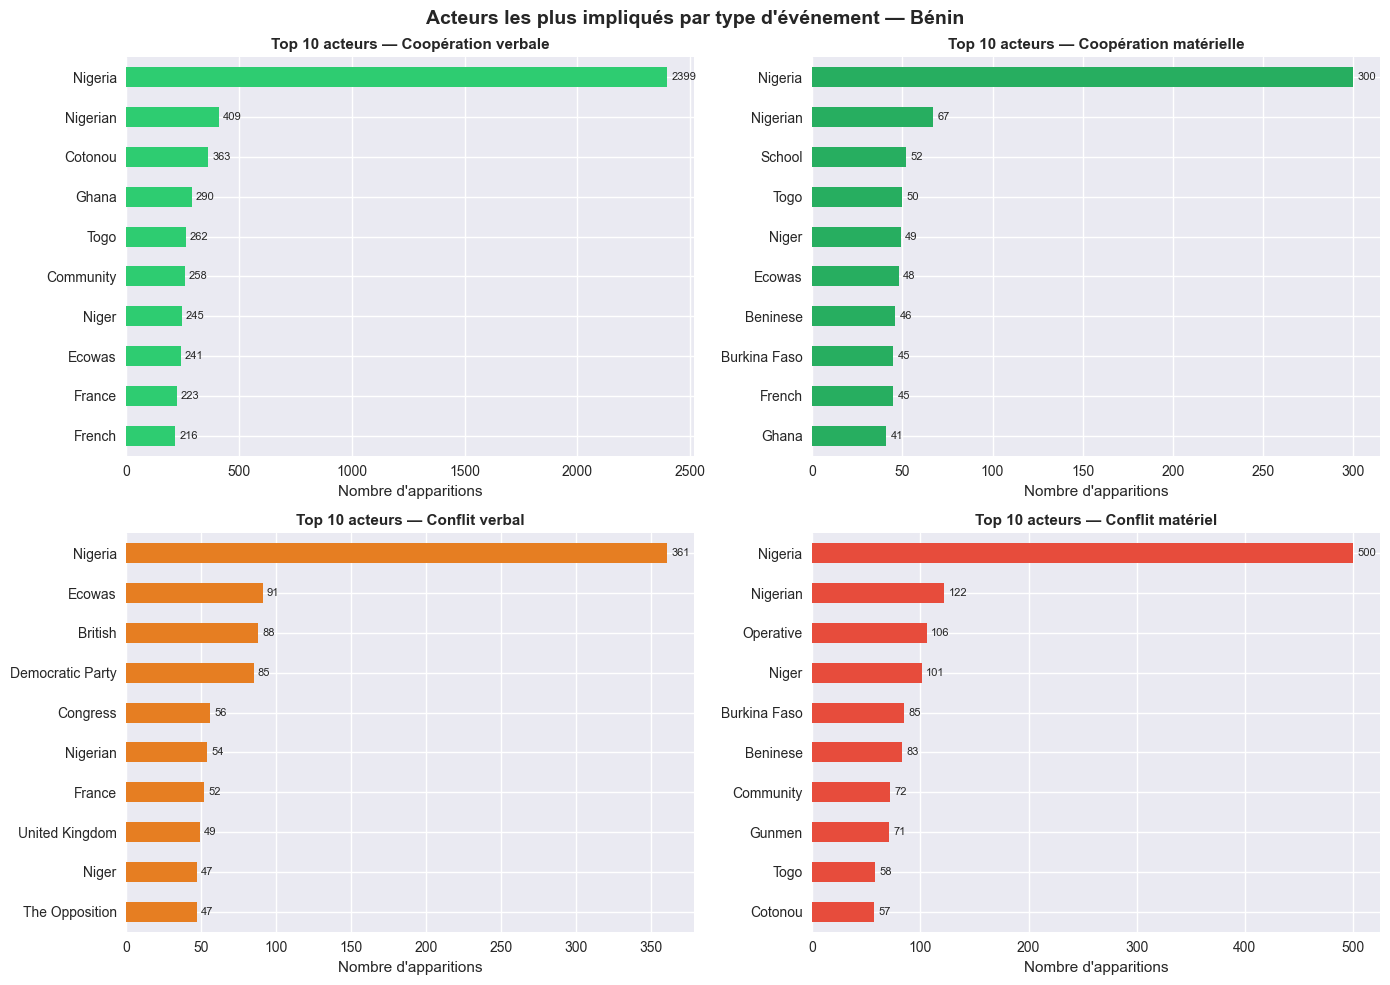

In [14]:
# ── Top acteurs par QuadClass ────────────────────────────────────────────────
quad_labels = ['Coopération verbale', 'Coopération matérielle',
               'Conflit verbal', 'Conflit matériel']
quad_colors = ['#2ecc71', '#27ae60', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (quad, color) in enumerate(zip(quad_labels, quad_colors)):
    top = (
        actors_df[actors_df['QuadLabel'] == quad]['ActorName']
        .value_counts()
        .head(10)
        .sort_values()
    )
    if top.empty:
        axes[idx].set_visible(False)
        continue
    top.plot(kind='barh', ax=axes[idx], color=color)
    axes[idx].set_title(f"Top 10 acteurs — {quad}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Nombre d'apparitions")
    axes[idx].set_ylabel("")
    axes[idx].bar_label(axes[idx].containers[0], padding=3, fontsize=8)

plt.suptitle("Acteurs les plus impliqués par type d'événement — Bénin", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


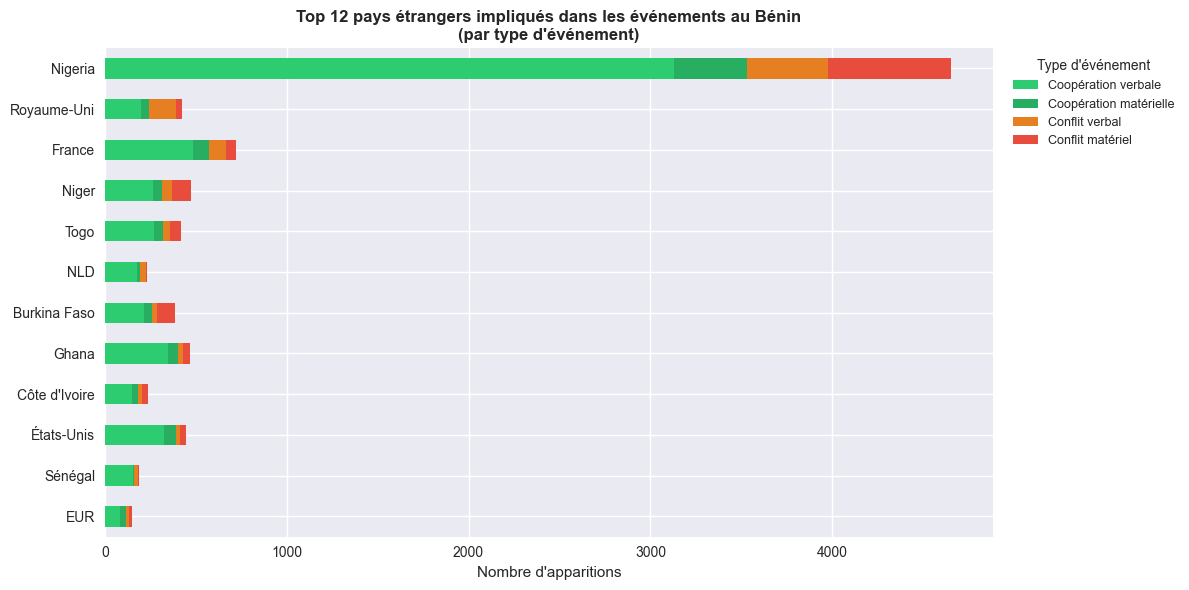


Top pays par type d'événement :
QuadLabel      Coopération verbale  Coopération matérielle  Conflit verbal  Conflit matériel
PaysNom                                                                                     
EUR                             84                      30              18                19
Sénégal                        156                       6              20                 8
États-Unis                     326                      67              21                31
Côte d'Ivoire                  148                      34              22                35
Ghana                          347                      56              26                40
Burkina Faso                   214                      46              27                98
NLD                            179                      14              32                 6
Togo                           269                      51              39                59
Niger                          264   

In [15]:
# ── Top pays étrangers par type d'événement ─────────────────────────────────
country_name_map = {
    'NGA': 'Nigeria', 'FRA': 'France', 'USA': 'États-Unis',
    'GHA': 'Ghana',   'TGO': 'Togo',   'NER': 'Niger',
    'GBR': 'Royaume-Uni', 'CHN': 'Chine', 'DEU': 'Allemagne',
    'CIV': "Côte d'Ivoire", 'MLI': 'Mali', 'BFA': 'Burkina Faso',
    'SEN': 'Sénégal', 'CMR': 'Cameroun', 'AFR': 'Afrique (générique)',
    'WAF': 'Afrique de l\'Ouest', 'EU': 'Union Européenne',
}

actors_pays = actors_df[
    actors_df['CountryCode'].notna() &
    (~actors_df['CountryCode'].isin(['BEN', 'AFR', 'WAF']))
].copy()
actors_pays['PaysNom'] = actors_pays['CountryCode'].map(country_name_map).fillna(actors_pays['CountryCode'])

pays_quad = (
    actors_pays.groupby(['PaysNom', 'QuadLabel'])
    .size()
    .unstack(fill_value=0)
    .loc[:, [c for c in quad_labels if c in actors_pays['QuadLabel'].unique()]]
)

top_pays = pays_quad.sum(axis=1).nlargest(12).index
pays_quad_top = pays_quad.loc[top_pays].sort_values('Conflit verbal' if 'Conflit verbal' in pays_quad.columns else pays_quad.columns[0])

fig, ax = plt.subplots(figsize=(12, 6))
pays_quad_top.plot(kind='barh', ax=ax, stacked=True,
                   color=[c for c, l in zip(quad_colors, quad_labels) if l in pays_quad_top.columns])
ax.set_title("Top 12 pays étrangers impliqués dans les événements au Bénin\n(par type d'événement)", fontsize=12, fontweight='bold')
ax.set_xlabel("Nombre d'apparitions")
ax.set_ylabel("")
ax.legend(title="Type d'événement", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop pays par type d'événement :")
print(pays_quad_top.to_string())


### 3.4 — Pics de couverture médiatique mondiale (Buzz)
**Objectif :** Identifier les moments où le Bénin a le plus attiré l'attention médiatique mondiale, et relier ces pics aux événements déclencheurs.


In [16]:
# Diagnostic : vérifier les colonnes disponibles pour le buzz
print("Colonnes disponibles dans df :")
print(df.columns.tolist())

Colonnes disponibles dans df :
['GLOBALEVENTID', 'SQLDATE', 'MonthYear', 'Year', 'FractionDate', 'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1Type1Code', 'Actor2Code', 'Actor2Name', 'Actor2CountryCode', 'Actor2Type1Code', 'IsRootEvent', 'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone', 'Actor1Geo_Type', 'Actor1Geo_FullName', 'Actor1Geo_CountryCode', 'Actor1Geo_ADM1Code', 'Actor1Geo_Lat', 'Actor1Geo_Long', 'Actor1Geo_FeatureID', 'Actor2Geo_Type', 'Actor2Geo_FullName', 'Actor2Geo_CountryCode', 'Actor2Geo_ADM1Code', 'Actor2Geo_Lat', 'Actor2Geo_Long', 'Actor2Geo_FeatureID', 'ActionGeo_Type', 'ActionGeo_FullName', 'ActionGeo_CountryCode', 'ActionGeo_ADM1Code', 'ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_FeatureID', 'DATEADDED', 'SOURCEURL', 'EventRootCode_str', 'EventRootLabel', 'Departement', 'QuadLabel', 'interaction_type']


In [17]:
from sklearn.preprocessing import MinMaxScaler

print("=" * 60)
print("Q3 — PICS DE COUVERTURE MÉDIATIQUE (BUZZ)")
print("=" * 60)

# ── Calcul du score de buzz ──────────────────────────────────────────────────
buzz_cols = [c for c in ['NumMentions', 'NumSources', 'NumArticles'] if c in df.columns]
print(f"\nColonnes utilisées pour le buzz : {buzz_cols}")

df_buzz = df[buzz_cols + ['SQLDATE', 'QuadLabel', 'EventRootLabel',
                           'Actor1Name', 'Actor2Name', 'ActionGeo_FullName',
                           'SOURCEURL']].copy()
df_buzz = df_buzz.dropna(subset=['SQLDATE'])

def normalize_sqldate(value):
    s = str(value).strip()
    if not s.isdigit() or len(s) not in {6, 7, 8}:
        return None
    if len(s) == 8:
        return s
    year, rest = s[:4], s[4:]
    if len(rest) == 3:
        cand1 = year + '0' + rest
        cand2 = year + rest[:2] + '0' + rest[2:]
        for candidate in (cand1, cand2):
            try:
                pd.to_datetime(candidate, format='%Y%m%d')
                return candidate
            except ValueError:
                continue
        return None
    if len(rest) == 2:
        cand = year + '0' + rest[0] + '0' + rest[1]
        try:
            pd.to_datetime(cand, format='%Y%m%d')
            return cand
        except ValueError:
            return None
    return None

df_buzz['SQLDATE'] = df_buzz['SQLDATE'].apply(normalize_sqldate)
valid_date_mask = df_buzz['SQLDATE'].notna()
if not valid_date_mask.all():
    print(f"⚠️ {len(df_buzz) - valid_date_mask.sum()} date(s) malformée(s) ignorée(s)")
    df_buzz = df_buzz[valid_date_mask].copy()

df_buzz['EventDate'] = pd.to_datetime(df_buzz['SQLDATE'], format='%Y%m%d', errors='coerce')
df_buzz = df_buzz.dropna(subset=['EventDate'])

scaler = MinMaxScaler()

df_buzz[[c + '_norm' for c in buzz_cols]] = scaler.fit_transform(df_buzz[buzz_cols].fillna(0))

weights = {'NumMentions': 0.4, 'NumSources': 0.4, 'NumArticles': 0.2}
df_buzz['buzz_score'] = sum(
    df_buzz[c + '_norm'] * weights.get(c, 0.33)
    for c in buzz_cols
)


Q3 — PICS DE COUVERTURE MÉDIATIQUE (BUZZ)

Colonnes utilisées pour le buzz : ['NumMentions', 'NumSources', 'NumArticles']


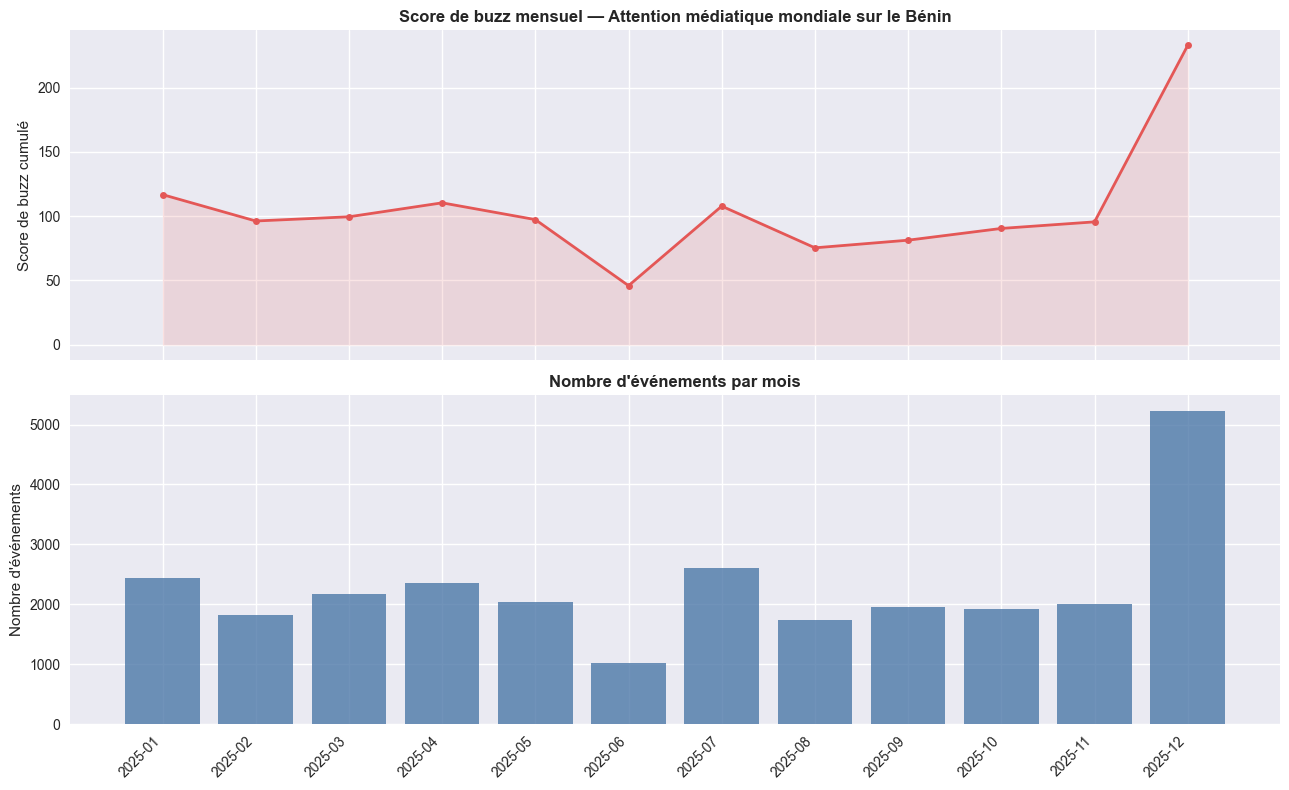


 Pic de buzz : 2025-12
   Score total  : 232.82
   Nb événements: 5229


In [18]:
# ── Buzz mensuel ────────────────────────────────────────────────────────────
df_buzz['month'] = df_buzz['EventDate'].dt.to_period('M').astype(str)

monthly_buzz = df_buzz.groupby('month').agg(
    buzz_total=('buzz_score', 'sum'),
    nb_evenements=('buzz_score', 'count'),
    mentions_total=('NumMentions', 'sum') if 'NumMentions' in df_buzz.columns else ('buzz_score', 'count'),
).reset_index()
monthly_buzz['month_str'] = monthly_buzz['month'].astype(str)
monthly_buzz = monthly_buzz.sort_values('month')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Score de buzz
axes[0].plot(monthly_buzz['month_str'], monthly_buzz['buzz_total'],
             marker='o', linewidth=2, color='#E45756', markersize=5)
axes[0].fill_between(range(len(monthly_buzz)), monthly_buzz['buzz_total'],
                     alpha=0.15, color='#E45756')
axes[0].set_title("Score de buzz mensuel — Attention médiatique mondiale sur le Bénin",
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel("Score de buzz cumulé")
axes[0].set_xticks(range(len(monthly_buzz)))
axes[0].set_xticklabels(monthly_buzz['month_str'], rotation=45, ha='right')

# Nombre d'événements
axes[1].bar(range(len(monthly_buzz)), monthly_buzz['nb_evenements'], color='#4C78A8', alpha=0.8)
axes[1].set_title("Nombre d'événements par mois", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Nombre d'événements")
axes[1].set_xticks(range(len(monthly_buzz)))
axes[1].set_xticklabels(monthly_buzz['month_str'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Identifier le pic
peak_month = monthly_buzz.loc[monthly_buzz['buzz_total'].idxmax()]
print(f"\n Pic de buzz : {peak_month['month_str']}")
print(f"   Score total  : {peak_month['buzz_total']:.2f}")
print(f"   Nb événements: {peak_month['nb_evenements']}")



Top 15 événements avec le plus fort buzz :
    EventDate               QuadLabel               EventRootLabel       Actor1Name  Actor2Name                       ActionGeo_FullName  buzz_score  NumMentions  NumSources  NumArticles
0  2025-12-10        Conflit matériel                   Coercition           PRISON         NaN                                    Benin    0.674576           28           7           28
1  2025-06-05        Conflit matériel      Réduction des relations            JUDGE       BENIN                                West Bank    0.628249           30           6           30
2  2025-03-19  Coopération matérielle            Aide / Assistance       WORLD BANK      GUINEA                                 Ethiopia    0.600000           60           1           60
3  2025-12-10     Coopération verbale     Coopération diplomatique  NICOLAS SARKOZY         NaN                                    Benin    0.596610           40           4           40
4  2025-12-11        

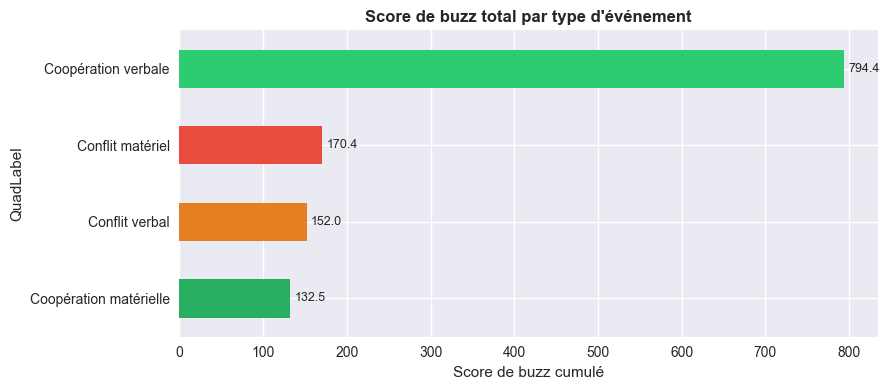

In [19]:
# ── Top 15 événements avec le plus fort buzz ────────────────────────────────
top_buzz_events = (
    df_buzz.nlargest(15, 'buzz_score')
    [['EventDate', 'QuadLabel', 'EventRootLabel', 'Actor1Name',
      'Actor2Name', 'ActionGeo_FullName', 'buzz_score'] +
     ([c for c in buzz_cols])]
    .reset_index(drop=True)
)

print("\nTop 15 événements avec le plus fort buzz :")
print(top_buzz_events.to_string())

# ── Buzz par type d'événement ────────────────────────────────────────────────
buzz_by_quad = df_buzz.groupby('QuadLabel')['buzz_score'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colors_quad = {
    'Coopération verbale': '#2ecc71', 'Coopération matérielle': '#27ae60',
    'Conflit verbal': '#e67e22', 'Conflit matériel': '#e74c3c', 'Inconnu': '#bdc3c7'
}
bar_colors = [colors_quad.get(l, '#aaa') for l in buzz_by_quad.index]
buzz_by_quad.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_title("Score de buzz total par type d'événement", fontsize=12, fontweight='bold')
ax.set_xlabel("Score de buzz cumulé")
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


### 3.5 — Top 10 médias couvrant le Bénin (Events + GKG)

**But :** Identifier les médias les plus actifs sur le Bénin, leur origine géographique,
et croiser avec le ton médiatique issu du GKG pour caractériser leur biais de couverture.

**Technique :**
- **Dataset Events** → extraction du domaine depuis `SOURCEURL` pour le classement par volume
- **Dataset GKG** → `SourceCommonName` pour enrichir l'identification et le ton moyen par média
- **Fusion** des deux sources pour obtenir : volume + origine + ton

> Un média très actif avec un tone systématiquement négatif est un signal important
> pour comprendre quel narratif domine la couverture internationale du Bénin.


In [20]:
from urllib.parse import urlparse

print("=" * 65)
print("Q1 — TOP 10 MÉDIAS COUVRANT LE BÉNIN (Events + GKG)")
print("=" * 65)

# ── Extraction des domaines depuis Events ────────────────────────────────────
def extract_domain(url):
    try:
        netloc = urlparse(str(url)).netloc
        return netloc.replace('www.', '').strip()
    except Exception:
        return None

df['media_domain'] = df['SOURCEURL'].apply(extract_domain)
df_media = df[
    df['media_domain'].notna() &
    (df['media_domain'] != '') &
    (df['media_domain'] != 'nan')
].copy()

top10_events = (
    df_media['media_domain']
    .value_counts()
    .head(10)
    .reset_index()
)
top10_events.columns = ['Domaine', 'Nb_evenements']

# ── Préparation GKG : tone moyen par SourceCommonName ────────────────────────
tone_cols_split = df_gkg['V2Tone'].astype(str).str.split(',', expand=True)
df_gkg['tone_global'] = pd.to_numeric(tone_cols_split[0], errors='coerce')

df_gkg['source_clean'] = (
    df_gkg['SourceCommonName'].astype(str)
    .str.strip()
    .replace({'nan': None, '': None})
)
df_gkg_src = df_gkg.dropna(subset=['source_clean', 'tone_global']).copy()

gkg_tone_by_source = (
    df_gkg_src.groupby('source_clean')
    .agg(
        nb_articles_gkg=('tone_global', 'count'),
        tone_moyen     =('tone_global', 'mean'),
        pct_negatif    =('tone_global', lambda x: (x < -2).mean() * 100),
    )
    .reset_index()
    .rename(columns={'source_clean': 'SourceCommonName'})
)

print(f"Sources uniques dans GKG : {df_gkg_src['source_clean'].nunique()}")
print(f"Sources uniques dans Events (domaines) : {df_media['media_domain'].nunique()}")


Q1 — TOP 10 MÉDIAS COUVRANT LE BÉNIN (Events + GKG)
Sources uniques dans GKG : 1288
Sources uniques dans Events (domaines) : 1382


In [33]:
# ── Mapping domaine Events → SourceCommonName GKG ───────────────────────────
# Permet de faire le pont entre les deux datasets
domain_to_source = {
    'allafrica.com':        'AllAfrica',
    'fr.allafrica.com':     'AllAfrica',
    'english.news.cn':      'Xinhua',
    'xinhuanet.com':        'Xinhua',
    'rfi.fr':               'RFI',
    'france24.com':         'France 24',
    'lemonde.fr':           'Le Monde',
    'reuters.com':          'Reuters',
    'bbc.com':              'BBC News',
    'bbc.co.uk':            'BBC News',
    'apnews.com':           'AP',
    'voanews.com':          'VOA News',
    'theguardian.com':      'The Guardian',
    'dw.com':               'DW',
    'premiumtimesng.com':   'Premium Times',
    'punchng.com':          'The Punch',
    'vanguardngr.com':      'Vanguard',
    'lanation.bj':          'La Nation Bénin',
    'ortb.bj':              'ORTB',
    'rfb.bj':               'RFB',
    'beninwebtv.com':       'Bénin Web TV',
    '24haubenin.com':       '24h au Bénin',
}

# ── Mapping origine géographique ─────────────────────────────────────────────
origine_media = {
    'La Nation Bénin': 'Bénin', 'ORTB': 'Bénin', 'RFB': 'Bénin',
    'Bénin Web TV': 'Bénin', '24h au Bénin': 'Bénin',
    'AllAfrica': 'Afrique (panafricain)', 'Africa Time': 'Afrique (panafricain)',
    'Africa News': 'Afrique (panafricain)', 'The Africa Report': 'Afrique (panafricain)',
    'RFI': 'France', 'France 24': 'France', 'Le Monde': 'France',
    'Reuters': 'Royaume-Uni', 'BBC News': 'Royaume-Uni', 'The Guardian': 'Royaume-Uni',
    'AP': 'États-Unis', 'VOA News': 'États-Unis',
    'Xinhua': 'Chine', 'DW': 'Allemagne',
    'Premium Times': 'Nigeria', 'The Punch': 'Nigeria', 'Vanguard': 'Nigeria',
}

# ── Construction du tableau fusionné ────────────────────────────────────────
top10_events['SourceCommonName'] = top10_events['Domaine'].map(domain_to_source)
top10_fused = top10_events.merge(
    gkg_tone_by_source,
    on='SourceCommonName',
    how='left'
)
top10_fused['Origine'] = top10_fused['SourceCommonName'].map(origine_media).fillna('Autre / Inconnu')
top10_fused['Rang']    = range(1, 11)

cols_display = ['Rang', 'Domaine', 'SourceCommonName', 'Nb_evenements',
                'nb_articles_gkg', 'Origine']
cols_present = [c for c in cols_display if c in top10_fused.columns]

print("\nTop 10 médias — fusion Events + GKG :")
print(top10_fused[cols_present].round(2).to_string(index=False))
print("\n Lecture du tableau :")
print("  Nb_evenements   → nombre d'événements GDELT couverts (Events)")
print("  nb_articles_gkg → nombre d'articles analysés (GKG)")




Top 10 médias — fusion Events + GKG :
 Rang                  Domaine SourceCommonName  Nb_evenements  nb_articles_gkg               Origine
    1             dailypost.ng              NaN           1750              NaN       Autre / Inconnu
    2              punchng.com        The Punch           1729              NaN               Nigeria
    3 nigerianobservernews.com              NaN           1137              NaN       Autre / Inconnu
    4            leadership.ng              NaN            883              NaN       Autre / Inconnu
    5              guardian.ng              NaN            770              NaN       Autre / Inconnu
    6            allafrica.com        AllAfrica            768              NaN Afrique (panafricain)
    7   lanouvelletribune.info              NaN            735              NaN       Autre / Inconnu
    8      saharareporters.com              NaN            595              NaN       Autre / Inconnu
    9                thesun.ng             

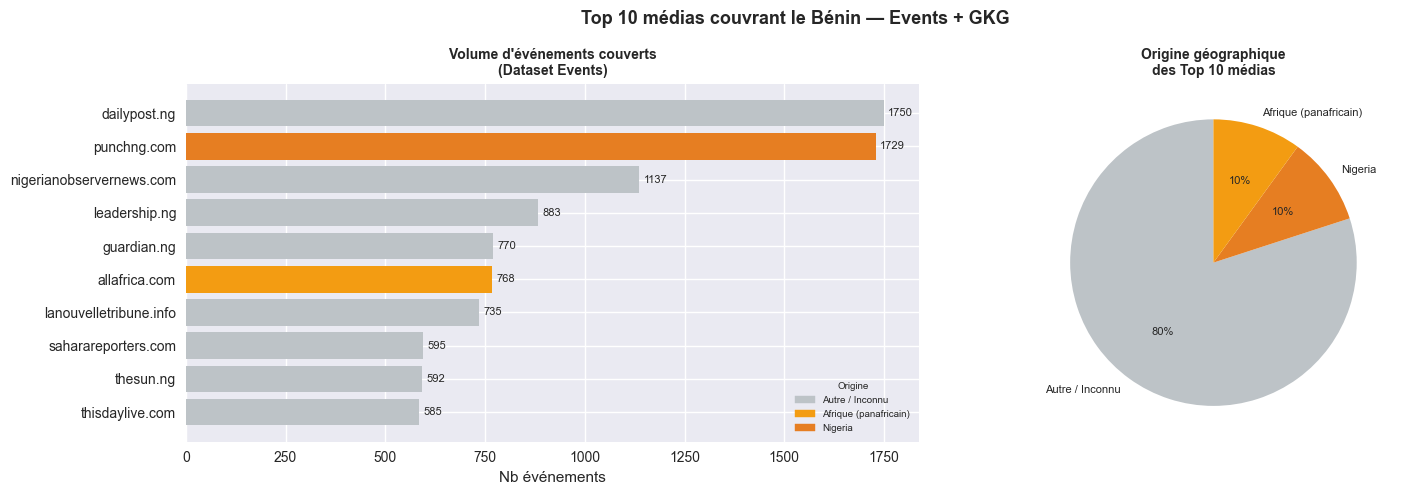


📌 Interprétation :
  - Le barplot de gauche classe les médias par volume d'événements couverts (Events).
  - Le graphique de droite montre l'origine géographique des médias les plus actifs.


In [37]:
# ── Visualisation Top 10 enrichie ────────────────────────────────────────────
region_colors = {
    'Bénin':                 '#27ae60',
    'Afrique (panafricain)': '#f39c12',
    'Chine':                 '#e74c3c',
    'France':                '#3498db',
    'Royaume-Uni':           '#9b59b6',
    'États-Unis':            '#1abc9c',
    'Nigeria':               '#e67e22',
    'Allemagne':             '#34495e',
    'Autre / Inconnu':       '#bdc3c7',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Barplot volume (Events) ──────────────────────────────────────────────────
top_sorted = top10_fused.sort_values('Nb_evenements')
bar_colors = [region_colors.get(o, '#bdc3c7') for o in top_sorted['Origine']]
axes[0].barh(top_sorted['Domaine'], top_sorted['Nb_evenements'], color=bar_colors)
axes[0].set_title("Volume d'événements couverts\n(Dataset Events)", fontsize=10, fontweight='bold')
axes[0].set_xlabel("Nb événements")
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=8)
from matplotlib.patches import Patch
patches = [Patch(color=region_colors.get(o, '#bdc3c7'), label=o)
           for o in top_sorted['Origine'].unique()]
axes[0].legend(handles=patches, title='Origine', fontsize=7, title_fontsize=7, loc='lower right')

# ── Pie origine ──────────────────────────────────────────────────────────────
origine_counts = top10_fused['Origine'].value_counts()
pie_colors = [region_colors.get(o, '#bdc3c7') for o in origine_counts.index]
axes[1].pie(origine_counts.values, labels=origine_counts.index,
            autopct='%1.0f%%', colors=pie_colors, startangle=90,
            textprops={'fontsize': 8})
axes[1].set_title("Origine géographique\ndes Top 10 médias", fontsize=10, fontweight='bold')

plt.suptitle("Top 10 médias couvrant le Bénin — Events + GKG",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Interprétation :")
print("  - Le barplot de gauche classe les médias par volume d'événements couverts (Events).")
print("  - Le graphique de droite montre l'origine géographique des médias les plus actifs.")


### 3.6 — Évolution du ton médiatique sur le Bénin (Q2)

**But :** Répondre à la question : *"À quel moment de l'année le ton de l'actualité
sur le Bénin était-il le plus négatif, le plus positif ?"*

**Source :** Dataset GKG — champ `V2Tone` qui encode 6 dimensions de sentiment
extraites du texte de chaque article.

**Technique :**
- Parsing du champ `V2Tone` (format CSV sur une ligne) en 6 colonnes numériques
- Agrégation mensuelle : tone moyen, polarité, % d'articles négatifs/positifs
- Identification des pics et creux avec annotation automatique sur les graphes

> **Rappel V2Tone :** `tone_global, positif, negatif, polarite, activite, auto_ref`
> Le `tone_global` est le score net (positif − négatif). Valeurs typiques : −10 à +10.
> La `polarite` mesure l'intensité émotionnelle indépendamment du signe.


In [24]:
# ── Parsing de V2Tone → 6 dimensions ────────────────────────────────────────
tone_col_names = ['tone_global', 'tone_positif', 'tone_negatif',
                  'polarite', 'activite', 'auto_ref']

tone_parsed = (
    df_gkg['V2Tone'].astype(str)
    .str.split(',', expand=True)
    .iloc[:, :6]
)
tone_parsed.columns = tone_col_names
df_gkg[tone_col_names] = tone_parsed.apply(pd.to_numeric, errors='coerce')

# ── Parsing de la date ───────────────────────────────────────────────────────
df_gkg['datetime']  = pd.to_datetime(
    df_gkg['Date'].astype(str).str[:8], format='%Y%m%d', errors='coerce'
)
df_gkg['month']     = df_gkg['datetime'].dt.to_period('M')
df_gkg['month_str'] = df_gkg['month'].astype(str)

df_gkg_tone = df_gkg.dropna(subset=['tone_global', 'datetime']).copy()

print(f"Articles GKG avec tone valide : {len(df_gkg_tone):,}")
print(f"Période : {df_gkg_tone['datetime'].min().date()} → {df_gkg_tone['datetime'].max().date()}")
print(f"\nStatistiques du tone global :")
print(df_gkg_tone['tone_global'].describe().round(3).to_string())
print(f"\n📌 Un tone moyen proche de 0 peut signifier soit une couverture neutre,")
print(f"   soit une couverture polarisée qui équilibre positif et négatif.")
print(f"   La polarité permet de distinguer ces deux cas.")


Articles GKG avec tone valide : 24,453
Période : 2025-01-01 → 2025-12-31

Statistiques du tone global :
count    24453.000
mean        -1.261
std          4.306
min        -18.519
25%         -4.299
50%         -1.235
75%          1.830
max         19.481

📌 Un tone moyen proche de 0 peut signifier soit une couverture neutre,
   soit une couverture polarisée qui équilibre positif et négatif.
   La polarité permet de distinguer ces deux cas.


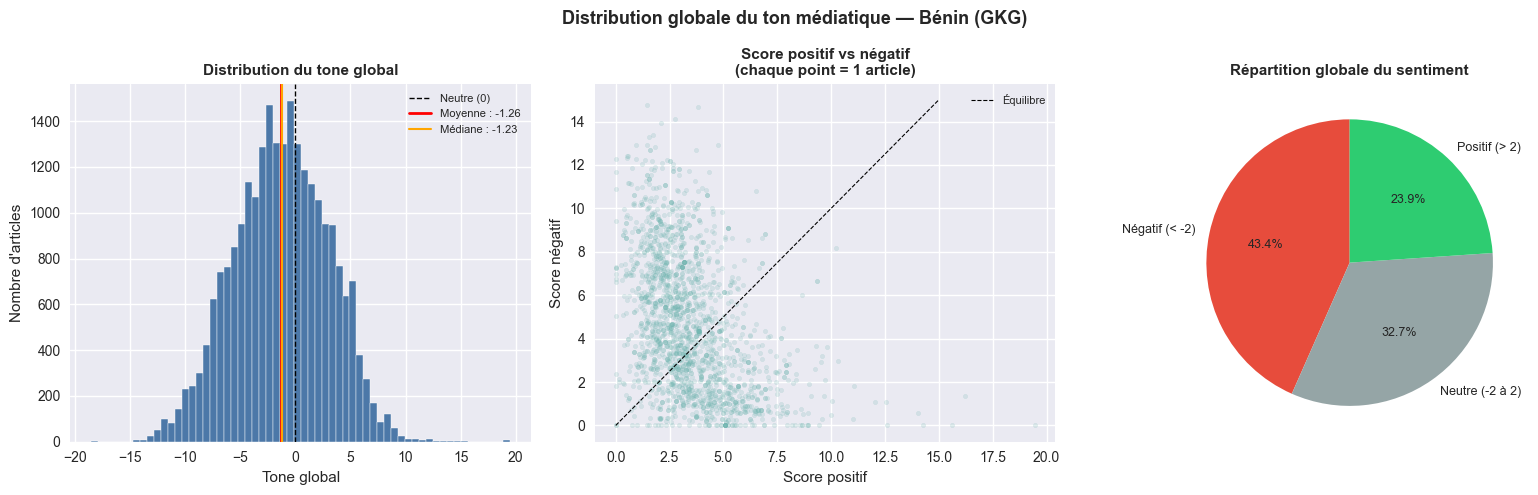


📌 Interprétation :
   43.4% des articles couvrent le Bénin négativement (tone < -2)
   23.9% des articles couvrent le Bénin positivement (tone > 2)
   32.7% des articles sont neutres
   La moyenne de -1.26 indique une couverture globalement
   négative sur la période analysée.


In [45]:
# ── 3.6.1 Distribution globale du ton ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tone_mean = df_gkg_tone['tone_global'].mean()
tone_med  = df_gkg_tone['tone_global'].median()

# Histogramme
axes[0].axvline(0,         color='black',  linestyle='--', linewidth=1,   label='Neutre (0)')
axes[0].axvline(tone_mean, color='red',    linestyle='-',  linewidth=2,
                label=f'Moyenne : {tone_mean:.2f}')
axes[0].axvline(tone_med,  color='orange', linestyle='-',  linewidth=1.5,
                label=f'Médiane : {tone_med:.2f}')
df_gkg_tone['tone_global'].hist(bins=60, ax=axes[0], color='#4C78A8', edgecolor='white')
axes[0].set_title('Distribution du tone global', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tone global')
axes[0].set_ylabel("Nombre d'articles")
axes[0].legend(fontsize=8)

# Scatter positif vs négatif
sample = df_gkg_tone.sample(min(2000, len(df_gkg_tone)), random_state=42)
axes[1].scatter(sample['tone_positif'], sample['tone_negatif'],
                alpha=0.2, s=10, color='#72B7B2')
axes[1].plot([0, 15], [0, 15], 'k--', linewidth=0.8, label='Équilibre')
axes[1].set_title('Score positif vs négatif\n(chaque point = 1 article)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Score positif')
axes[1].set_ylabel('Score négatif')
axes[1].legend(fontsize=8)

# Pie 3 catégories
df_gkg_tone['sentiment_cat'] = pd.cut(
    df_gkg_tone['tone_global'],
    bins=[-100, -2, 2, 100],
    labels=['Négatif (< -2)', 'Neutre (-2 à 2)', 'Positif (> 2)']
)
sent_counts = df_gkg_tone['sentiment_cat'].value_counts()
axes[2].pie(sent_counts.values, labels=sent_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c','#95a5a6','#2ecc71'],
            startangle=90, textprops={'fontsize': 9})
axes[2].set_title('Répartition globale du sentiment', fontsize=11, fontweight='bold')

plt.suptitle('Distribution globale du ton médiatique — Bénin (GKG)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pct_neg = (df_gkg_tone['tone_global'] < -2).mean() * 100
pct_pos = (df_gkg_tone['tone_global'] > 2).mean() * 100
pct_neu = 100 - pct_neg - pct_pos
print(f"\n📌 Interprétation :")
print(f"   {pct_neg:.1f}% des articles couvrent le Bénin négativement (tone < -2)")
print(f"   {pct_pos:.1f}% des articles couvrent le Bénin positivement (tone > 2)")
print(f"   {pct_neu:.1f}% des articles sont neutres")
print(f"   La moyenne de {tone_mean:.2f} indique une couverture globalement")
print(f"   {'négative' if tone_mean < 0 else 'positive'} sur la période analysée.")


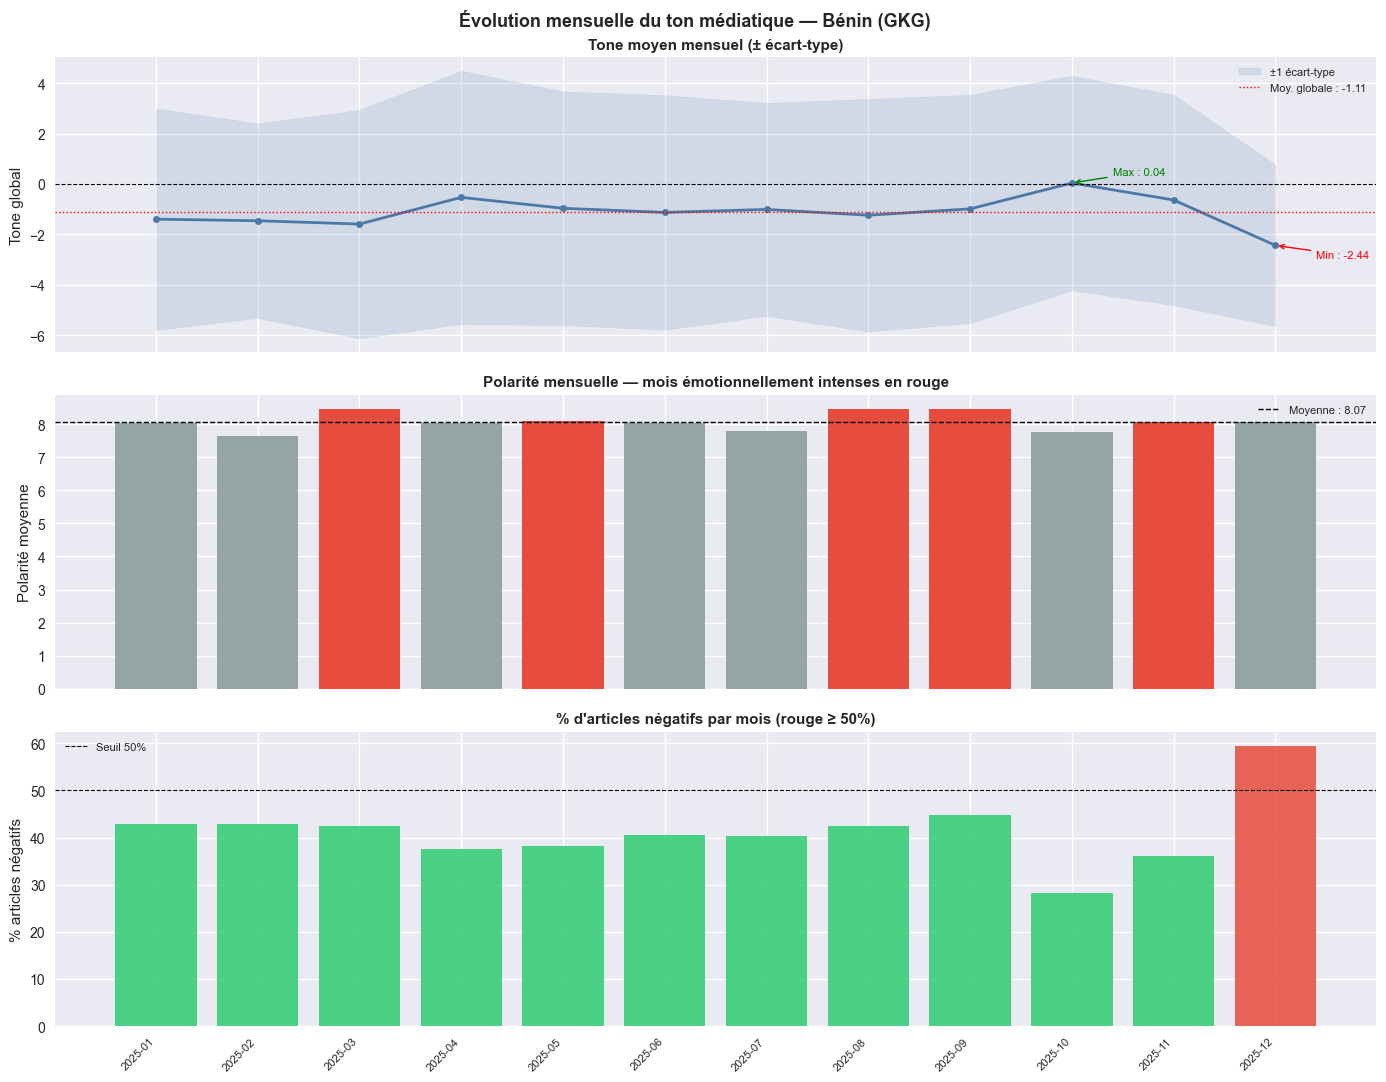


📌 Interprétation :
   Mois le plus négatif  : 2025-12 (tone = -2.442)
   Mois le plus positif  : 2025-10 (tone = 0.036)
   Mois le plus polarisé : 2025-09 — couverture émotionnellement intense,
   même si le ton net semble modéré.
   L'écart-type élevé sur certains mois indique des opinions médiatiques divisées.


In [27]:
# ── 3.6.2 Évolution mensuelle du ton ────────────────────────────────────────
monthly_tone = df_gkg_tone.groupby('month_str').agg(
    tone_moyen  =('tone_global', 'mean'),
    tone_std    =('tone_global', 'std'),
    polarite_moy=('polarite',    'mean'),
    nb_articles =('tone_global', 'count'),
    pct_negatif =('tone_global', lambda x: (x < -2).mean() * 100),
    pct_positif =('tone_global', lambda x: (x > 2).mean()  * 100),
).reset_index().sort_values('month_str')

months = range(len(monthly_tone))
labels = monthly_tone['month_str'].tolist()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# ── Tone moyen ± écart-type ──────────────────────────────────────────────────
axes[0].plot(months, monthly_tone['tone_moyen'],
             marker='o', linewidth=2, color='#4C78A8', markersize=5)
axes[0].fill_between(months,
    monthly_tone['tone_moyen'] - monthly_tone['tone_std'],
    monthly_tone['tone_moyen'] + monthly_tone['tone_std'],
    alpha=0.15, color='#4C78A8', label='±1 écart-type')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].axhline(monthly_tone['tone_moyen'].mean(), color='red', linestyle=':',
                linewidth=1, label=f"Moy. globale : {monthly_tone['tone_moyen'].mean():.2f}")

# Annoter min et max
idx_min = monthly_tone['tone_moyen'].idxmin()
idx_max = monthly_tone['tone_moyen'].idxmax()
pos_min = list(monthly_tone.index).index(idx_min)
pos_max = list(monthly_tone.index).index(idx_max)

for pos, idx, color, label in [
    (pos_min, idx_min, 'red',   f"Min : {monthly_tone.loc[idx_min,'tone_moyen']:.2f}"),
    (pos_max, idx_max, 'green', f"Max : {monthly_tone.loc[idx_max,'tone_moyen']:.2f}"),
]:
    axes[0].annotate(label,
        xy=(pos, monthly_tone.loc[idx,'tone_moyen']),
        xytext=(pos + 0.4, monthly_tone.loc[idx,'tone_moyen'] + (0.3 if color=='green' else -0.5)),
        fontsize=8, color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1))

axes[0].set_title('Tone moyen mensuel (± écart-type)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tone global')
axes[0].legend(fontsize=8)

# ── Polarité mensuelle ───────────────────────────────────────────────────────
moy_pol = monthly_tone['polarite_moy'].mean()
pol_colors = ['#e74c3c' if p > moy_pol else '#95a5a6' for p in monthly_tone['polarite_moy']]
axes[1].bar(months, monthly_tone['polarite_moy'], color=pol_colors)
axes[1].axhline(moy_pol, color='black', linestyle='--', linewidth=1,
                label=f'Moyenne : {moy_pol:.2f}')
axes[1].set_title('Polarité mensuelle — mois émotionnellement intenses en rouge',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Polarité moyenne')
axes[1].legend(fontsize=8)

# ── % articles négatifs par mois ─────────────────────────────────────────────
neg_colors = ['#e74c3c' if v >= 50 else '#2ecc71' for v in monthly_tone['pct_negatif']]
axes[2].bar(months, monthly_tone['pct_negatif'], color=neg_colors, alpha=0.85)
axes[2].axhline(50, color='black', linestyle='--', linewidth=0.8, label='Seuil 50%')
axes[2].set_title("% d'articles négatifs par mois (rouge ≥ 50%)",
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('% articles négatifs')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xticks(list(months))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

plt.suptitle("Évolution mensuelle du ton médiatique — Bénin (GKG)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mois_neg = monthly_tone.loc[idx_min, 'month_str']
mois_pos = monthly_tone.loc[idx_max, 'month_str']
mois_pol = monthly_tone.loc[monthly_tone['polarite_moy'].idxmax(), 'month_str']
print(f"\n📌 Interprétation :")
print(f"   Mois le plus négatif  : {mois_neg} (tone = {monthly_tone['tone_moyen'].min():.3f})")
print(f"   Mois le plus positif  : {mois_pos} (tone = {monthly_tone['tone_moyen'].max():.3f})")
print(f"   Mois le plus polarisé : {mois_pol} — couverture émotionnellement intense,")
print(f"   même si le ton net semble modéré.")
print(f"   L'écart-type élevé sur certains mois indique des opinions médiatiques divisées.")


## 4. Première version d'un modèle de Machine Learning

### Contexte et choix du modèle

Le livrable exige une **première version d'un modèle ML** dans le notebook EDA.
Nous implémentons ici deux modèles complémentaires :

**Modèle 1 — Clustering K-Means (non supervisé)**
Regrouper les événements en profils similaires selon leurs caractéristiques
numériques (`GoldsteinScale`, `AvgTone`, `NumMentions`, `NumSources`).
Objectif : découvrir des patterns que les catégories CAMEO ne capturent pas.

**Modèle 2 — Classification QuadClass (supervisé)**
Prédire la grande catégorie d'un événement (QuadClass 1-4) à partir
de ses caractéristiques. Objectif : valider que les features numériques
sont suffisamment discriminantes pour un modèle de classification.



In [46]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              silhouette_score, ConfusionMatrixDisplay)

print("=" * 60)
print("MACHINE LEARNING — PREMIÈRE VERSION")
print("=" * 60)

# ── Features communes aux deux modèles ───────────────────────────────────────
ML_FEATURES = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumSources']
ml_cols     = ML_FEATURES + ['QuadClass', 'QuadLabel']
ml_cols_ok  = [c for c in ml_cols if c in df.columns]

df_ml = df[ml_cols_ok].dropna(subset=ML_FEATURES).copy()

# Supprimer les outliers extrêmes sur NumMentions
q99 = df_ml['NumMentions'].quantile(0.99)
df_ml = df_ml[df_ml['NumMentions'] <= q99]

print(f"\nDataset ML : {len(df_ml):,} événements")
print(f"Features   : {ML_FEATURES}")
print(f"\nDistribution QuadClass :")
print(df_ml['QuadLabel'].value_counts().to_string())

# Normalisation
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[ML_FEATURES])
print(f"\n✅ Features normalisées (StandardScaler)")


MACHINE LEARNING — PREMIÈRE VERSION

Dataset ML : 27,268 événements
Features   : ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumSources']

Distribution QuadClass :
QuadLabel
Coopération verbale       17564
Conflit matériel           3697
Conflit verbal             3257
Coopération matérielle     2750

✅ Features normalisées (StandardScaler)



──────────────────────────────────────────────────
MODÈLE 1 — CLUSTERING K-MEANS
──────────────────────────────────────────────────


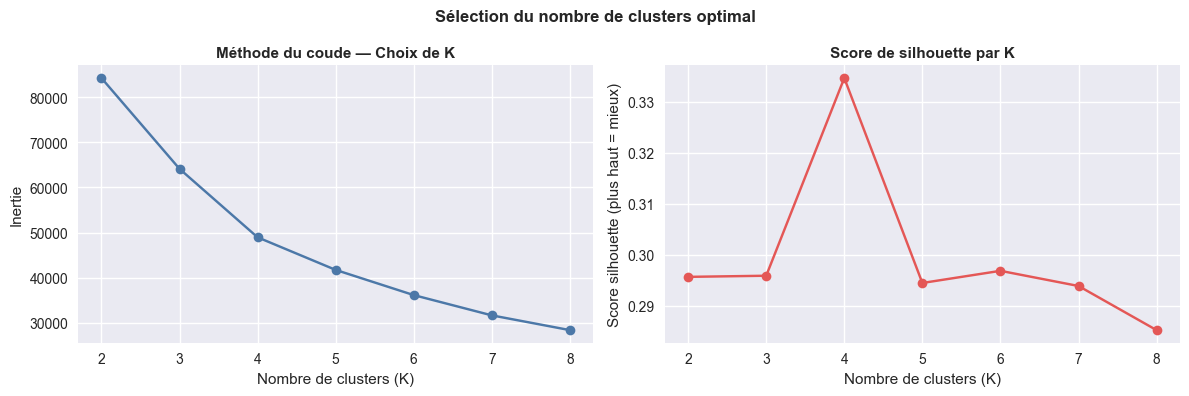


K optimal (silhouette max) : 4
Score silhouette           : 0.335

 La méthode du coude identifie le K où l'inertie
   cesse de décroître significativement.
   Le score de silhouette confirme la qualité de la séparation.


In [47]:
# ── Modèle 1 : Clustering K-Means ────────────────────────────────────────────
print("\n" + "─" * 50)
print("MODÈLE 1 — CLUSTERING K-MEANS")
print("─" * 50)

# Méthode du coude pour choisir k
inertias   = []
silhouettes = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='#4C78A8')
axes[0].set_title('Méthode du coude — Choix de K', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')

axes[1].plot(list(K_range), silhouettes, marker='o', color='#E45756')
axes[1].set_title('Score de silhouette par K', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Score silhouette (plus haut = mieux)')

plt.suptitle('Sélection du nombre de clusters optimal', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"\nK optimal (silhouette max) : {best_k}")
print(f"Score silhouette           : {max(silhouettes):.3f}")
print(f"\n La méthode du coude identifie le K où l'inertie")
print(f"   cesse de décroître significativement.")
print(f"   Le score de silhouette confirme la qualité de la séparation.")



Profil moyen des clusters :
         GoldsteinScale  AvgTone  NumMentions  NumSources
cluster                                                  
0                 2.905    0.295        2.901       1.000
1                 2.428   -0.288       10.092       1.000
2                -0.485   -2.425        9.038       2.181
3                -5.063   -5.412        4.852       1.000

Répartition QuadClass par cluster :
QuadLabel  Conflit matériel  Conflit verbal  Coopération matérielle  Coopération verbale
cluster                                                                                 
0                        47             441                    1573                10496
1                       111             551                     935                 5773
2                        41              45                      26                  126
3                      3498            2220                     216                 1169


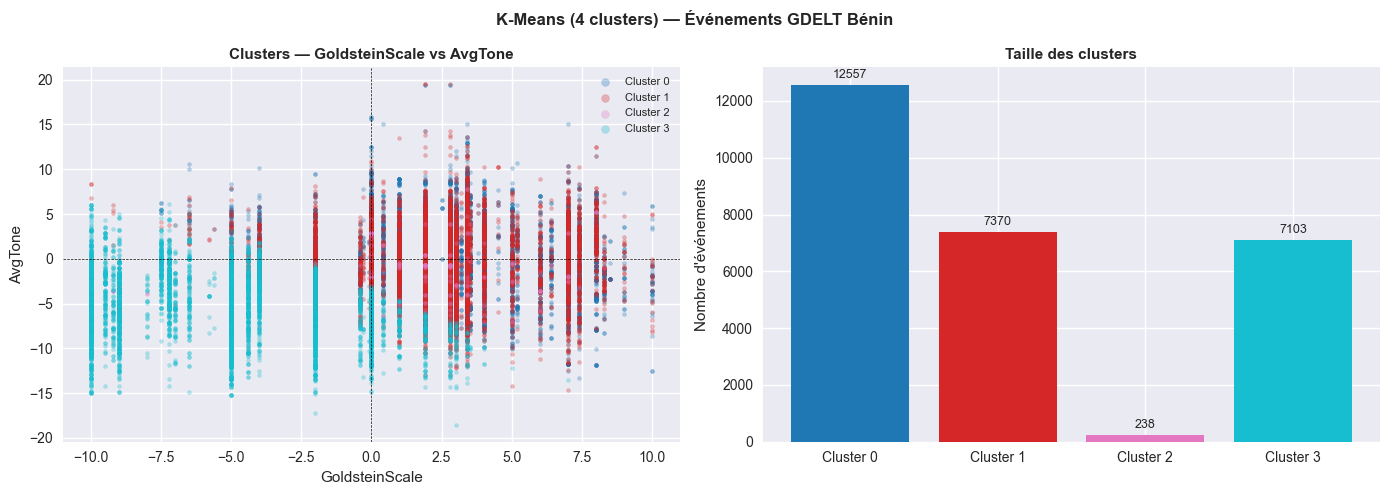


 Interprétation des clusters :
   Cluster 0 → coopératif/positif (Goldstein=2.90, Tone=0.29)
   Cluster 1 → mixte (Goldstein=2.43, Tone=-0.29)
   Cluster 2 → conflictuel/négatif (Goldstein=-0.48, Tone=-2.42)
   Cluster 3 → conflictuel/négatif (Goldstein=-5.06, Tone=-5.41)


In [48]:
# ── Entraînement final K-Means avec best_k ───────────────────────────────────
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_ml['cluster'] = kmeans_final.fit_predict(X_scaled)

# Profil moyen de chaque cluster
cluster_profile = (
    df_ml.groupby('cluster')[ML_FEATURES]
    .mean()
    .round(3)
)
print("\nProfil moyen des clusters :")
print(cluster_profile.to_string())

# Lien entre cluster et QuadClass
if 'QuadLabel' in df_ml.columns:
    cluster_quad = (
        df_ml.groupby(['cluster', 'QuadLabel'])
        .size()
        .unstack(fill_value=0)
    )
    print("\nRépartition QuadClass par cluster :")
    print(cluster_quad.to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter GoldsteinScale vs AvgTone colorié par cluster
colors_cluster = plt.cm.tab10(np.linspace(0, 1, best_k))
for i in range(best_k):
    mask = df_ml['cluster'] == i
    axes[0].scatter(df_ml.loc[mask, 'GoldsteinScale'],
                    df_ml.loc[mask, 'AvgTone'],
                    s=8, alpha=0.3, color=colors_cluster[i],
                    label=f'Cluster {i}')
axes[0].set_xlabel('GoldsteinScale')
axes[0].set_ylabel('AvgTone')
axes[0].set_title('Clusters — GoldsteinScale vs AvgTone', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8, markerscale=2)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.5)

# Taille des clusters
cluster_sizes = df_ml['cluster'].value_counts().sort_index()
axes[1].bar([f'Cluster {i}' for i in cluster_sizes.index],
            cluster_sizes.values, color=colors_cluster[:len(cluster_sizes)])
axes[1].set_title('Taille des clusters', fontsize=11, fontweight='bold')
axes[1].set_ylabel("Nombre d'événements")
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)

plt.suptitle(f'K-Means ({best_k} clusters) — Événements GDELT Bénin',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Interprétation des clusters :")
for i, row in cluster_profile.iterrows():
    gs, tone = row['GoldsteinScale'], row['AvgTone']
    profil = ('coopératif/positif' if gs > 0 and tone > 0
              else 'conflictuel/négatif' if gs < 0 and tone < 0
              else 'mixte')
    print(f"   Cluster {i} → {profil} (Goldstein={gs:.2f}, Tone={tone:.2f})")



──────────────────────────────────────────────────
MODÈLE 2 — CLASSIFICATION QUADCLASS (Random Forest)
──────────────────────────────────────────────────
Train : 21,814 | Test : 5,454

Accuracy : 0.935

Rapport de classification :
                  precision    recall  f1-score   support

   Coop. verbale       0.99      0.96      0.98      3513
Coop. matérielle       0.79      0.80      0.79       550
  Conflit verbal       0.82      0.88      0.85       651
Conflit matériel       0.90      0.95      0.93       740

        accuracy                           0.93      5454
       macro avg       0.88      0.90      0.89      5454
    weighted avg       0.94      0.93      0.94      5454



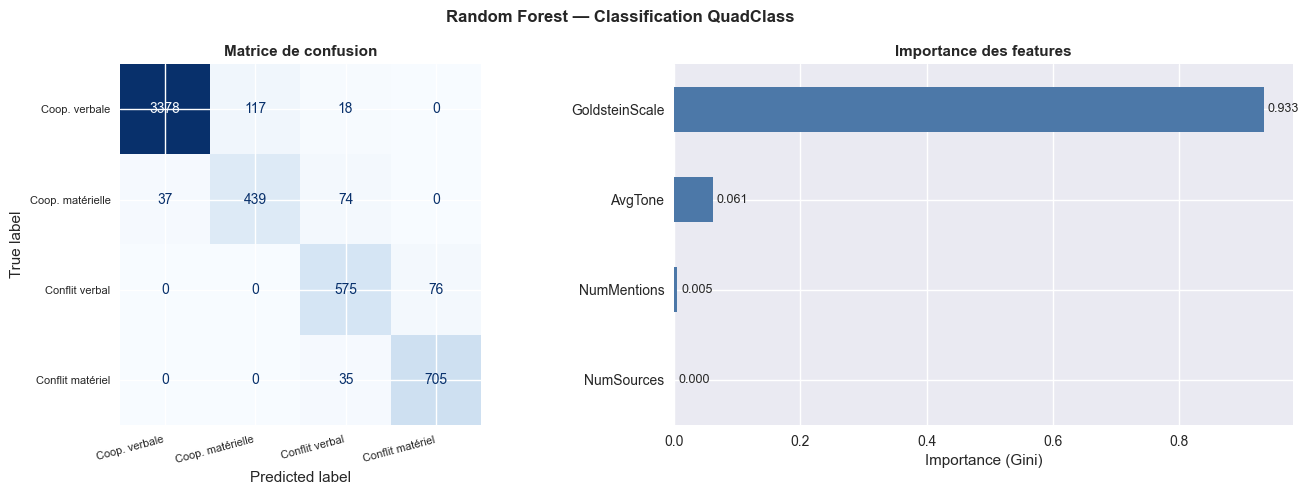


 Interprétation :
   Feature la plus discriminante : GoldsteinScale
   Le GoldsteinScale et l'AvgTone sont les signaux les plus forts
   pour distinguer un événement coopératif d'un événement conflictuel.
   → Ces features seront centrales dans le notebook ML approfondi.


In [49]:
# ── Modèle 2 : Classification RandomForest → QuadClass ──────────────────────
print("\n" + "─" * 50)
print("MODÈLE 2 — CLASSIFICATION QUADCLASS (Random Forest)")
print("─" * 50)

if 'QuadClass' not in df_ml.columns:
    print(" Colonne QuadClass absente — classification ignorée.")
else:
    X = df_ml[ML_FEATURES]
    y = df_ml['QuadClass']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")

    rf = RandomForestClassifier(
        n_estimators=100, max_depth=8,
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print(f"\nAccuracy : {(y_pred == y_test).mean():.3f}")
    print("\nRapport de classification :")

    quad_names = {1:'Coop. verbale', 2:'Coop. matérielle',
                  3:'Conflit verbal', 4:'Conflit matériel'}
    target_names = [quad_names.get(c, str(c)) for c in sorted(y.unique())]
    print(classification_report(y_test, y_pred, target_names=target_names))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Matrice de confusion', fontsize=11, fontweight='bold')
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=8)
    plt.setp(axes[0].yaxis.get_majorticklabels(), fontsize=8)

    # Importance des features
    feat_imp = pd.Series(rf.feature_importances_, index=ML_FEATURES).sort_values()
    feat_imp.plot(kind='barh', ax=axes[1], color='#4C78A8')
    axes[1].set_title('Importance des features', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Importance (Gini)')
    axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=3, fontsize=9)

    plt.suptitle('Random Forest — Classification QuadClass', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n Interprétation :")
    top_feat = feat_imp.index[-1]
    print(f"   Feature la plus discriminante : {top_feat}")
    print(f"   Le GoldsteinScale et l'AvgTone sont les signaux les plus forts")
    print(f"   pour distinguer un événement coopératif d'un événement conflictuel.")
    print(f"   → Ces features seront centrales dans le notebook ML approfondi.")


## 5. Synthèse globale — Insights & Conclusions

---

### Dataset Events — Faits et acteurs

| Dimension | Insight |
|-----------|---------|
| **Type d'événement dominant** | Coopération verbale |
| **Département le plus actif** | Borgou |
| **Part internationale d'acteurs** | 46,7 % |
| **Pic de buzz** | Décembre |
| **Média le plus actif (Events)** | Dailypost |

---

### Dataset GKG — Perception médiatique

| Dimension | Insight |
|-----------|---------|
| **Ton global** | Négative sur la période analysée |
| **Mois le plus négatif** | Décembre |
| **Mois le plus positif** | Octobre |


---

>Le mois le plus négatif correspond au mois où le Bénin a fait le plus de buzz. On en déduit que des données analysées sur cette période les sujets négatifs sont ceux qui font le plus parlé du Bénin dans le monde en 2025

### Machine Learning — Résultats v1

| Modèle | Résultat |
|--------|----------|
| **K-Means clustering** | Best K = 4 |
| **Random Forest accuracy** | 0.935 |
| **Feature la plus discriminante** | GoldsteinScale |

---

### Ce que ces données disent au décideur public

> *La feature GoldsteinScale est la plus discriminante pour classifier les evènements répertorié.
> Donc le nombre total de mentions de l'évenements dans tous les articles est très indicatif pour savoir si un évenements est coopératif ou conflictuel*

**Exemple de structure attendue :**
1. *"Sur la période analysée, X% de la couverture du Bénin était négative..."*
2. *"Le mois de [mois] a concentré le plus fort buzz, coïncidant avec..."*
3. *"Les départements du nord concentrent [X]% des événements conflictuels..."*
4. *"Les médias [noms] dominent le narratif international avec un ton [qualificatif]..."*
5. *"Les événements coopératifs représentent [X]% mais génèrent moins de buzz que..."*

---

> **Prochaine étape :** `notebooks/04_ml_sentiment.ipynb` — analyse de sentiment avancée avec GKG
